In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")

In [2]:
# Cell 2: Load data + basic info
df = pd.read_csv(r"C:\Users\admin\Downloads\archive (1).zip")   # <-- update path if needed

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (6497, 13)

Head:
    fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality color  
0      9.4        5   red  
1   

In [3]:
# Cell 3: Clean data — nulls + IQR outlier removal
target_col = "quality"
feature_cols = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
                 "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
                 "density", "pH", "sulphates", "alcohol", "color"]

print("Rows before cleaning:", df.shape[0])

# Handle nulls
df = df.dropna()
print("Rows after dropping nulls:", df.shape[0])

# Encode categorical 'color' column (red/white) before outlier handling
le_color = LabelEncoder()
df["color"] = le_color.fit_transform(df["color"])   # e.g. red=0/1, white=1/0

# IQR-based outlier removal (only on numeric continuous columns, not color/quality)
numeric_cols_for_outliers = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
                              "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
                              "density", "pH", "sulphates", "alcohol"]

def remove_outliers_iqr(data, cols):
    data = data.copy()
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

rows_before = df.shape[0]
df = remove_outliers_iqr(df, numeric_cols_for_outliers)
rows_after = df.shape[0]

print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

df = df.reset_index(drop=True)

Rows before cleaning: 6497
Rows after dropping nulls: 6497
Rows before outlier removal: 6497
Rows after outlier removal: 4596
Rows removed: 1901


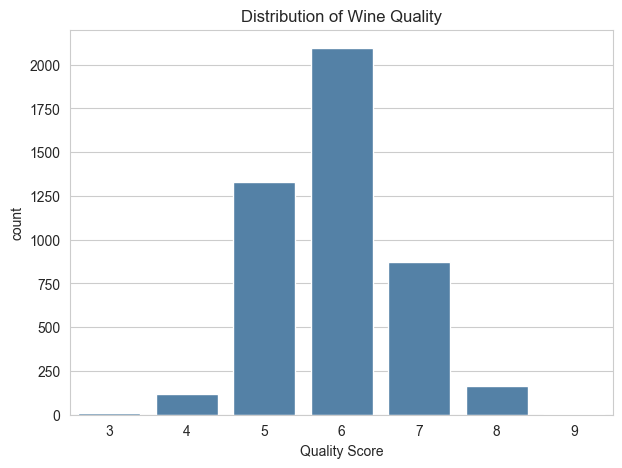

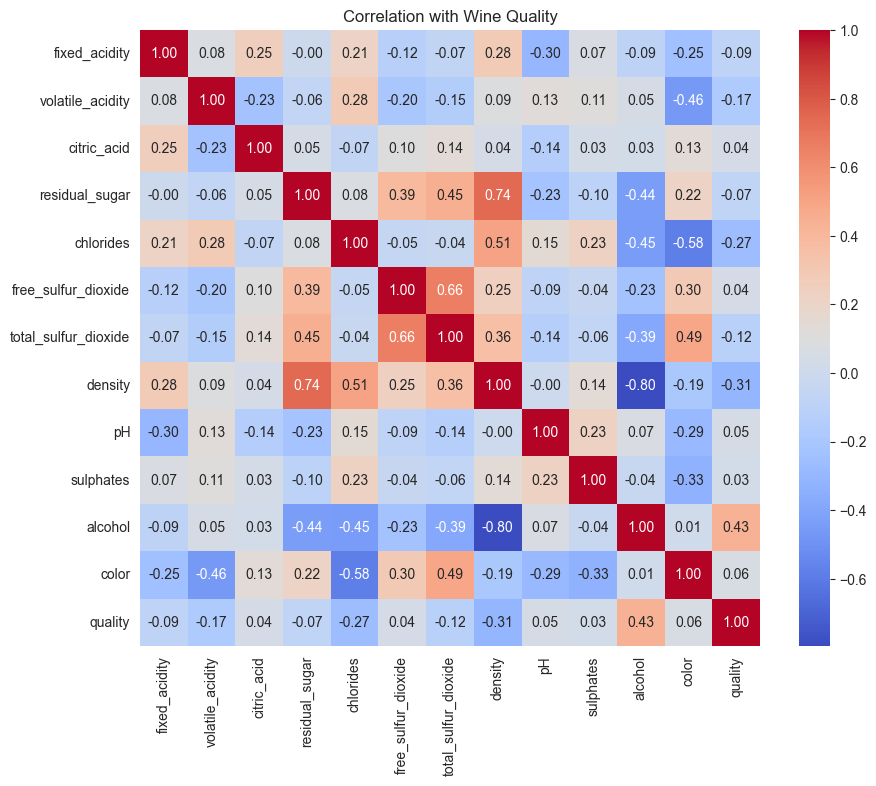

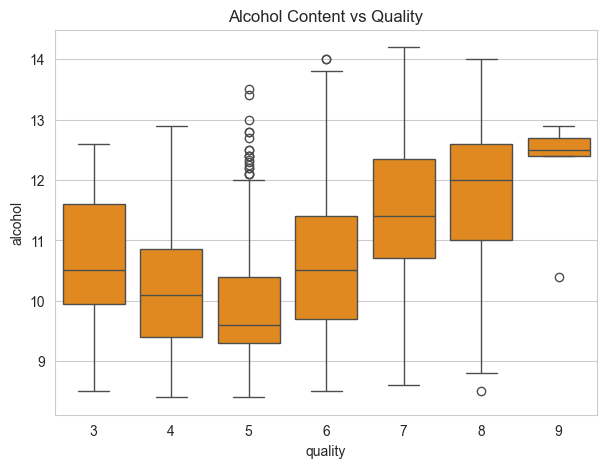

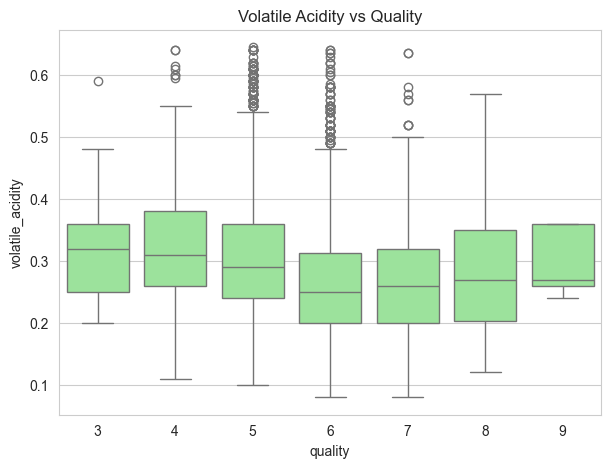

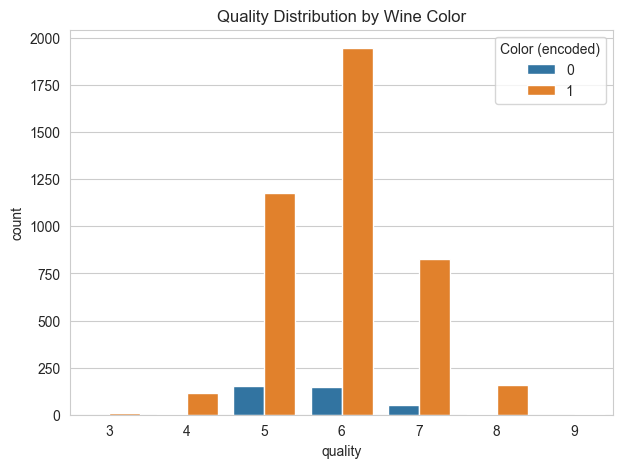

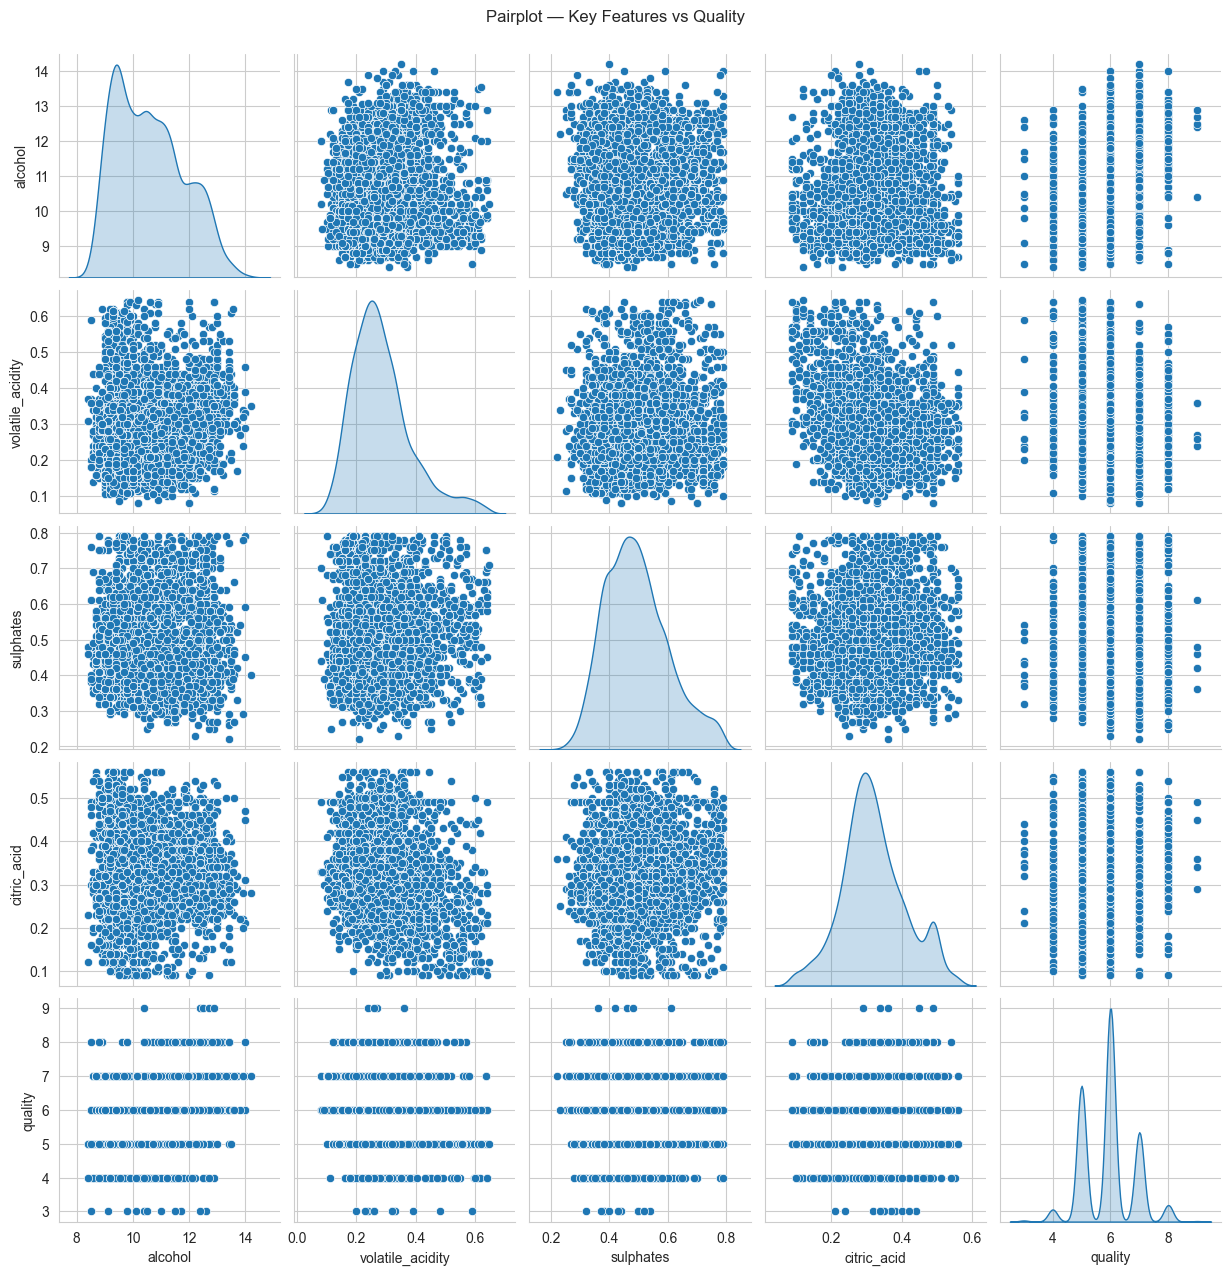

In [4]:
# Cell 4: Visualizations — all centered on wine quality

# 4.1 Distribution of quality
plt.figure(figsize=(7,5))
sns.countplot(x=df[target_col], color="steelblue")
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.show()

# 4.2 Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[feature_cols + [target_col]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Wine Quality")
plt.show()

# 4.3 Alcohol vs Quality
plt.figure(figsize=(7,5))
sns.boxplot(x=df[target_col], y=df["alcohol"], color="darkorange")
plt.title("Alcohol Content vs Quality")
plt.show()

# 4.4 Volatile Acidity vs Quality
plt.figure(figsize=(7,5))
sns.boxplot(x=df[target_col], y=df["volatile_acidity"], color="lightgreen")
plt.title("Volatile Acidity vs Quality")
plt.show()

# 4.5 Quality distribution by color (0/1 encoded)
plt.figure(figsize=(7,5))
sns.countplot(x=df[target_col], hue=df["color"])
plt.title("Quality Distribution by Wine Color")
plt.legend(title="Color (encoded)")
plt.show()

# 4.6 Pairplot of key features vs quality
sns.pairplot(df[["alcohol", "volatile_acidity", "sulphates", "citric_acid", target_col]], diag_kind="kde")
plt.suptitle("Pairplot — Key Features vs Quality", y=1.02)
plt.show()

In [5]:
# Cell 5: Train-test split + feature scaling
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (3676, 12) X_test: (920, 12)


In [6]:
# Cell 6: Train and compare models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model  Train R2   Test R2  Train RMSE  Test RMSE  Train MAE  \
0      Random Forest  0.932735  0.513749    0.225898   0.585383   0.160778   
1            XGBoost  0.829304  0.439902    0.359856   0.628264   0.269353   
2  Gradient Boosting  0.489679  0.374038    0.622213   0.664177   0.491025   
3              Ridge  0.265933  0.263419    0.746251   0.720477   0.580412   
4  Linear Regression  0.265934  0.263399    0.746251   0.720487   0.580432   
5              Lasso  0.257262  0.259517    0.750646   0.722383   0.583087   

   Test MAE  
0  0.424049  
1  0.473811  
2  0.522832  
3  0.568243  
4  0.568240  
5  0.571701  


Best Model: Random Forest
Train R2: 0.9327 | Test R2: 0.5137
Train RMSE: 0.2259 | Test RMSE: 0.5854
Verdict: Overfitting — large gap between train and test performance.


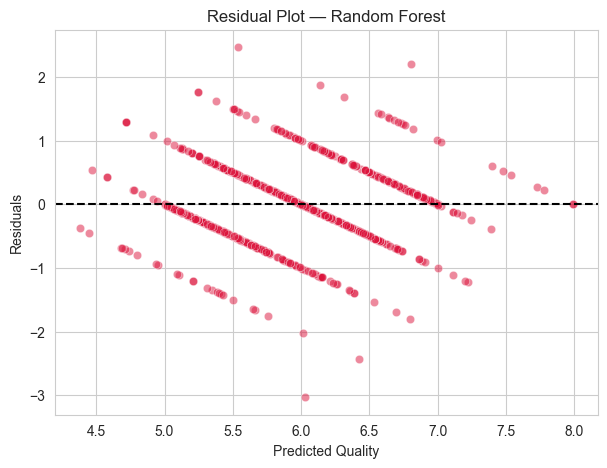

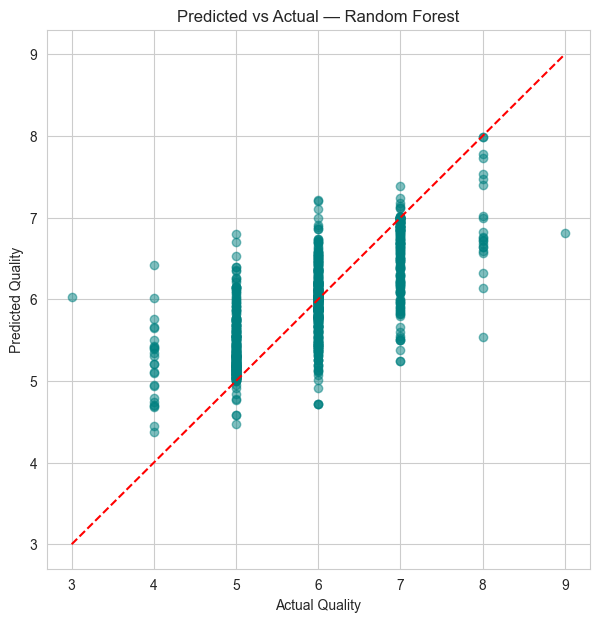

In [7]:
# Cell 7: Evaluate best model for overfitting/underfitting
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best Model:", best_model_name)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

gap = train_r2 - test_r2
if gap > 0.1:
    verdict = "Overfitting — large gap between train and test performance."
elif train_r2 < 0.5 and test_r2 < 0.5:
    verdict = "Underfitting — model performs poorly on both train and test."
else:
    verdict = "Good fit — train and test performance are close and reasonably high."
print("Verdict:", verdict)

# Residual plot
residuals = y_test - y_test_pred
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5, color="crimson")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

# Predicted vs Actual plot
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

In [8]:
# Cell 8: Test best model on 5 random test rows
sample_idx = np.random.choice(range(len(X_test)), 5, replace=False)
sample_X = X_test[sample_idx]
sample_actual = y_test.values[sample_idx]
sample_pred = best_model.predict(sample_X)

comparison_df = pd.DataFrame({
    "Actual": sample_actual,
    "Predicted": sample_pred,
    "Error %": np.abs((sample_actual - sample_pred) / sample_actual) * 100
})
print(comparison_df)

   Actual  Predicted    Error %
0       6      6.455   7.583333
1       6      6.685  11.416667
2       6      5.780   3.666667
3       5      6.795  35.900000
4       6      5.875   2.083333


In [10]:
# Cell 9: Manual input prediction (all 11 features required, not just 5)
print("Enter values for the following features:")
fixed_acidity = float(input("Fixed Acidity: "))
volatile_acidity = float(input("Volatile Acidity: "))
citric_acid = float(input("Citric Acid: "))
residual_sugar = float(input("Residual Sugar: "))
chlorides = float(input("Chlorides: "))
free_sulfur_dioxide = float(input("Free Sulfur Dioxide: "))
total_sulfur_dioxide = float(input("Total Sulfur Dioxide: "))
density = float(input("Density: "))
pH = float(input("pH: "))
sulphates = float(input("Sulphates: "))
alcohol = float(input("Alcohol: "))
color_input = input("Color (red/white): ").strip().lower()
color_encoded = le_color.transform([color_input])[0]

manual_input = pd.DataFrame([[fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                               chlorides, free_sulfur_dioxide, total_sulfur_dioxide,
                               density, pH, sulphates, alcohol, color_encoded]],
                             columns=feature_cols)
manual_input_scaled = scaler.transform(manual_input)

predicted_quality = best_model.predict(manual_input_scaled)
print(f"\nPredicted Wine Quality: {predicted_quality[0]:.2f}")


Enter values for the following features:


Fixed Acidity:  7.4
Volatile Acidity:  0.7
Citric Acid:  0
Residual Sugar:  1.9
Chlorides:  0.076
Free Sulfur Dioxide:  11
Total Sulfur Dioxide:  34
Density:  0.9978
pH:  3.51
Sulphates:  0.56
Alcohol:  9.4
Color (red/white):  red



Predicted Wine Quality: 5.49


In [11]:
# Cell 10: Save model and scaler
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_color, "color_encoder.pkl")
print("Saved: best_model.pkl, scaler.pkl, color_encoder.pkl")

Saved: best_model.pkl, scaler.pkl, color_encoder.pkl
